Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.2782 - val_loss: 0.1882
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1703 - val_loss: 0.1537
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1446 - val_loss: 0.1343
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1293 - val_loss: 0.1224
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1191 - val_loss: 0.1140
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


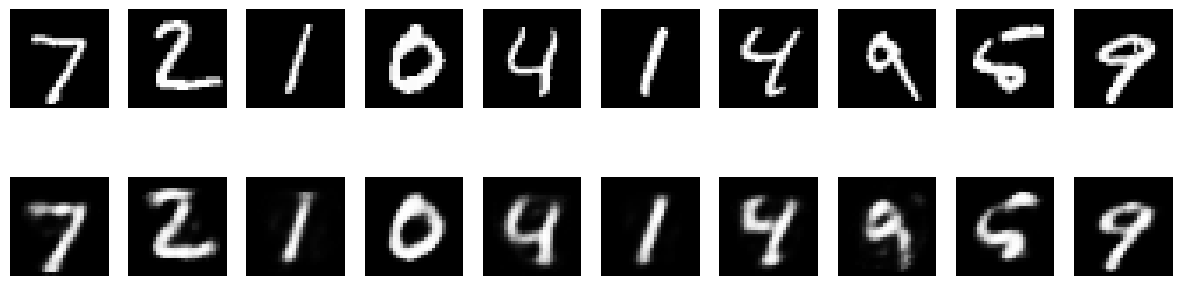

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(X_train, _), (X_test, _) = mnist.load_data()
X_train = X_train.reshape(-1, 784).astype("float32") / 255.0
X_test = X_test.reshape(-1, 784).astype("float32") / 255.0

input_img = tf.keras.Input(shape=(784,))
encoded = layers.Dense(32, activation="relu")(input_img)
decoded = layers.Dense(784, activation="sigmoid")(encoded)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

autoencoder.fit(X_train, X_train, epochs=5, batch_size=256, validation_data=(X_test, X_test))

decoded_imgs = autoencoder.predict(X_test)

plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()